# Assignment 06

Sabarno Saha, 22MS037.

## Problem 1

Game theoretic moran process

Prisoner dilemma payoff,

M = [[3,0],[5,1]]



In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
# NJIT is needed, otherwise the complete double loop takes around 20 mins to run
from numba import njit


# Use the scienceplots package for nicer plot themes.
import scienceplots
plt.style.use(['science'])

# Just some config to make plots legible in pdfs
plt.rcParams.update({'font.size': 20,  'axes.labelweight': 'bold', 'font.family': 'sans-serif', 'legend.fontsize': 15})

In [ ]:
    

@njit
def tftalld_moran4(N, T_max, M, pop0, rounds):
    pop = np.zeros(T_max)
    pop = pop0.copy()
    
    
    # A change in formatting from my previous code. 
    # Instead of calculating payoffs for each pairwise interaction, 
    # I calculate the payoffs before the loop and then just assign
    # them based on the strategies of the interacting individuals
    pay_TFT_TFT = rounds * M[0, 0]
    pay_TFT_AllD = M[0, 1] + (rounds - 1) * M[1, 1] 
    pay_AllD_TFT = M[1, 0] + (rounds - 1) * M[1, 1] 
    pay_AllD_AllD = rounds * M[1, 1]

    for t in range(1, T_max):
        current_pop = pop.copy()
        payoffs = np.zeros(N)
        
        # 1. Random Pair-wise interaction for EACH member 
        indices = np.random.permutation(N)
        
        for i in range(0, N - (N % 2), 2):
            p1 = indices[i]
            p2 = indices[i+1]
            
            strat1 = current_pop[p1]
            strat2 = current_pop[p2]
            
            if strat1 == 0 and strat2 == 0:
                payoffs[p1] = pay_TFT_TFT
                payoffs[p2] = pay_TFT_TFT
            elif strat1 == 0 and strat2 == 1:
                payoffs[p1] = pay_TFT_AllD
                payoffs[p2] = pay_AllD_TFT
            elif strat1 == 1 and strat2 == 0:
                payoffs[p1] = pay_AllD_TFT
                payoffs[p2] = pay_TFT_AllD
            else:
                payoffs[p1] = pay_AllD_AllD
                payoffs[p2] = pay_AllD_AllD
                
        cumulative_fitness = payoffs + 1.0 
        
        sum_fitness = np.sum(cumulative_fitness)
        prob_dist = cumulative_fitness / sum_fitness
        
        
        
        # One could just use random.choices here, 
        # but probability distributions in choice are not supported by numba.
        r = np.random.random()
        cum_prob = 0.0
        rep_index = N - 1  
        for i in range(N):
            cum_prob += prob_dist[i]
            if r < cum_prob:
                rep_index = i
                break
                
        death_index = np.random.randint(0, N)      
        
        pop[death_index] = pop[rep_index]  
        # Check Fixation
        current_sum = np.sum(pop)
        if current_sum == 0:
            return pop, t
        if current_sum == N:
            return pop, t
            
    print("No fixation within T_max generations")
    return pop, T_max   
    

In [ ]:

@njit
def tftalld_moran_fix(Nvals, T_max, M, rounds, Nt):
    
    tftfix = np.zeros(len(Nvals))
    alldfix = np.zeros(len(Nvals))
    for i in range(len(Nvals)):
        N = Nvals[i]
        pop0 = np.ones(N)
        index = np.random.randint(N)
        pop0[index] = 0
        # print(sum(pop0))
        for _ in range(Nt):
            pop, T = tftalld_moran4(N,T_max,M,pop0, rounds)
            if sum(pop) == 0:
                tftfix[i] += 1
            else:
                alldfix[i] += 1

        tftfix[i] = N*tftfix[i] / Nt
        alldfix[i] = N*alldfix[i] / Nt
        print(N)
        print(tftfix[i])
        
    return tftfix, alldfix


In [ ]:
# %%time
Nt = 5000

# N = 600

T_max = int(1e5)


rounds= 10

M = np.array([[3,0],[5,1]])

Nvals = np.asarray([100,200,300,400,600,800,1000])
tftfix, alldfix = tftalld_moran_fix(Nvals, T_max, M, rounds, Nt)

print(tftfix)
  

100
4.48
200
4.52
300
3.36
400
3.04
600
1.92
800
1.92
1000
0.8
[4.48 4.52 3.36 3.04 1.92 1.92 0.8 ]
CPU times: user 19min 10s, sys: 954 ms, total: 19min 11s
Wall time: 19min 13s


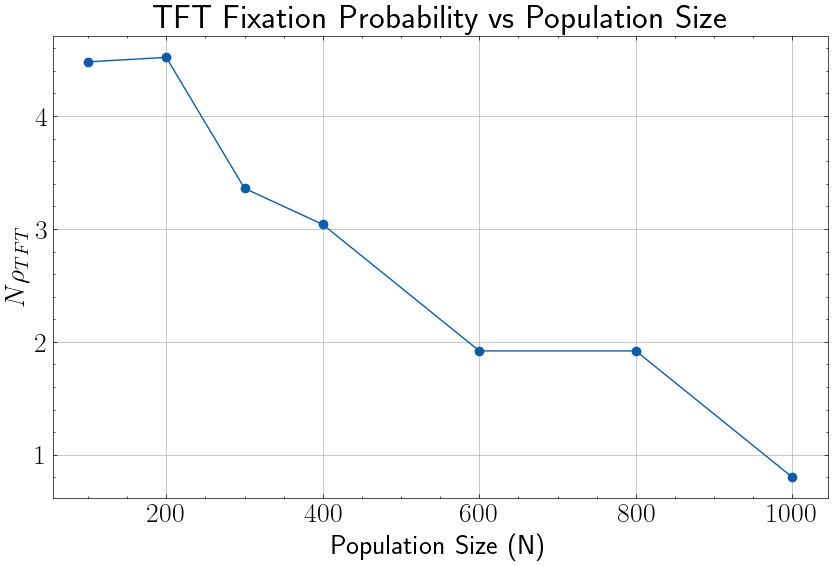

In [36]:
plt.figure(figsize=(10,6))
plt.plot(Nvals, tftfix, label='TFT Fixation', marker='o')
plt.xlabel('Population Size (N)')
plt.grid()
plt.ylabel(r'$N \rho_{TFT}$')
plt.title('TFT Fixation Probability vs Population Size')
plt.savefig('tft_fixation_probability.png',dpi=300)